In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier


In [ ]:
np.random.seed(42)
N = 2000  # number of samples

data = []

for _ in range(N):
    broken = np.round(np.random.uniform(0, 30), 2)
    foreign = np.round(np.random.uniform(0, 5), 2)
    moisture = np.round(np.random.uniform(8, 15), 2)
    whole = np.round(100 - broken - foreign, 2)

    # Grade Logic (Best → Worst)
    if broken <= 2 and foreign <= 0.5 and moisture <= 11:
        grade = "A+"
    elif broken <= 5 and foreign <= 1 and moisture <= 12:
        grade = "A"
    elif broken <= 8 and foreign <= 2 and moisture <= 13:
        grade = "B+"
    elif broken <= 12 and foreign <= 3 and moisture <= 13.5:
        grade = "B"
    elif broken <= 18 and foreign <= 4 and moisture <= 14:
        grade = "C+"
    else:
        grade = "C"

    data.append([whole, broken, foreign, moisture, grade])

df = pd.DataFrame(data, columns=[
    "whole_grain",
    "broken_grain",
    "foreign_matter",
    "moisture",
    "grade"
])

df.to_csv("truegrade_dataset.csv", index=False)
df.head()


,whole_grain,broken_grain,foreign_matter,moisture,grade
0,84.01,11.24,4.75,13.12,C
1,81.26,17.96,0.78,9.09,C+
2,93.93,1.74,4.33,12.21,C
3,78.66,21.24,0.10,14.79,C
4,73.97,24.97,1.06,9.27,C


In [ ]:
df['grade'].value_counts()


,count
grade,
C,1216
C+,403
B,229
B+,122
A,27
A+,3


In [ ]:
X = df[["whole_grain", "broken_grain", "foreign_matter", "moisture"]]
y = df["grade"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.985

Classification Report:

              precision    recall  f1-score   support

           A       0.75      0.60      0.67         5
          A+       0.00      0.00      0.00         1
           B       0.96      0.98      0.97        46
          B+       0.92      1.00      0.96        24
           C       1.00      1.00      1.00       243
          C+       1.00      0.98      0.99        81

    accuracy                           0.98       400
   macro avg       0.77      0.76      0.76       400
weighted avg       0.98      0.98      0.98       400



In [ ]:
# ===============================
# TRUEGRADE LIVE PREDICTION DEMO
# ===============================

# Sample input (manual / sensor / lab values)
input_sample = {
    "whole_grain": 91.2,
    "broken_grain": 4.1,
    "foreign_matter": 0.9,
    "moisture": 11.6
}

input_df = pd.DataFrame([input_sample])

# Scale input
input_scaled = scaler.transform(input_df)

# Predict grade
predicted_class = model.predict(input_scaled)
predicted_grade = label_encoder.inverse_transform(predicted_class)

# Prediction confidence
confidence = np.max(model.predict_proba(input_scaled)) * 100

print("🔍 TRUEGRADE QUALITY REPORT")
print("----------------------------")
print(f"Predicted Grade : {predicted_grade[0]}")
print(f"Confidence      : {confidence:.2f}%")

print("\n📊 Input Parameters")
display(input_df)


🔍 TRUEGRADE QUALITY REPORT
----------------------------
Predicted Grade : B+
Confidence      : 52.94%

📊 Input Parameters


,whole_grain,broken_grain,foreign_matter,moisture
0,91.2,4.1,0.9,11.6


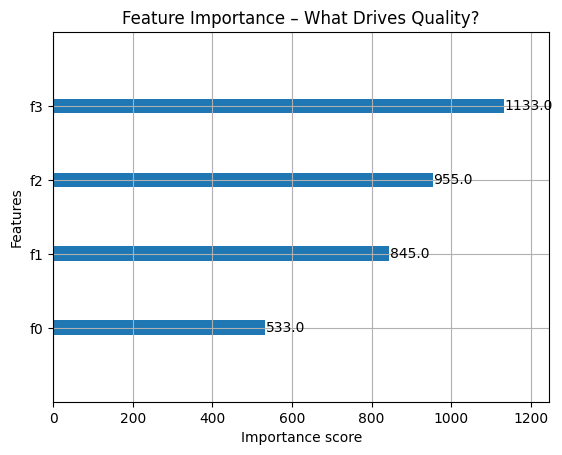

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=5)
plt.title("Feature Importance – What Drives Quality?")
plt.show()


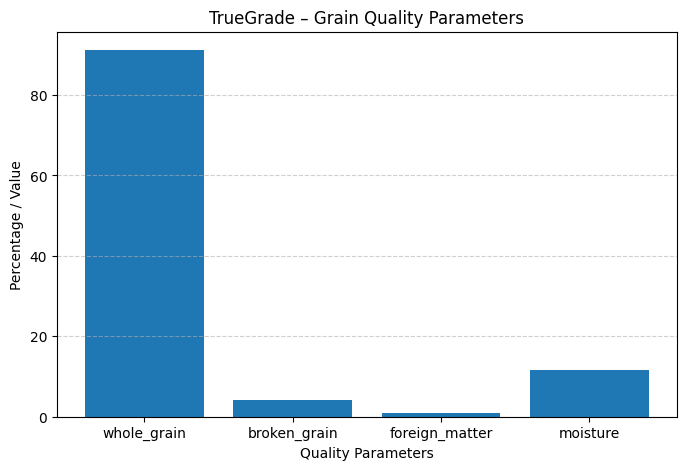

In [ ]:
import matplotlib.pyplot as plt

# Extract values
params = list(input_sample.keys())
values = list(input_sample.values())

plt.figure(figsize=(8,5))
plt.bar(params, values)
plt.title("TrueGrade – Grain Quality Parameters")
plt.xlabel("Quality Parameters")
plt.ylabel("Percentage / Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


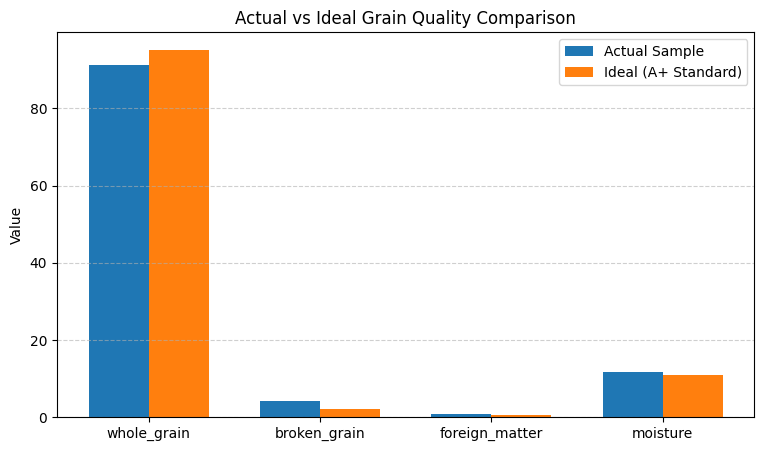

In [ ]:
# Ideal limits for A+ grade (reference)
ideal_limits = {
    "whole_grain": 95,
    "broken_grain": 2,
    "foreign_matter": 0.5,
    "moisture": 11
}

ideal_values = list(ideal_limits.values())

x = np.arange(len(params))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, values, width, label="Actual Sample")
plt.bar(x + width/2, ideal_values, width, label="Ideal (A+ Standard)")

plt.xticks(x, params)
plt.ylabel("Value")
plt.title("Actual vs Ideal Grain Quality Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
